In [35]:
import juliet
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.gridspec as gd
import multiprocessing
import matplotlib as mpl
multiprocessing.set_start_method('fork')

mpl.rcParams.update({
    "font.family": "serif",  # Use a serif font for a more professional look
    "font.size": 12,  # Adjust font size for better readability
    "axes.labelsize": 14,  # Label size
    "axes.titlesize": 16,  # Title size
    "xtick.labelsize": 12,  # Tick label size
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "lines.linewidth": 1.5,  # Thicker lines for better visibility
    "axes.linewidth": 1.2,  # Thicker axes lines
    "figure.dpi": 300,  # High-resolution figures
    "savefig.dpi": 300,  # High resolution when saving figures
    "savefig.format": "pdf",  # Save in vector format for publications
    "text.usetex": False  # Use LaTeX for better typography (optional)
})

# print('juliet version: ', juliet.__version__)

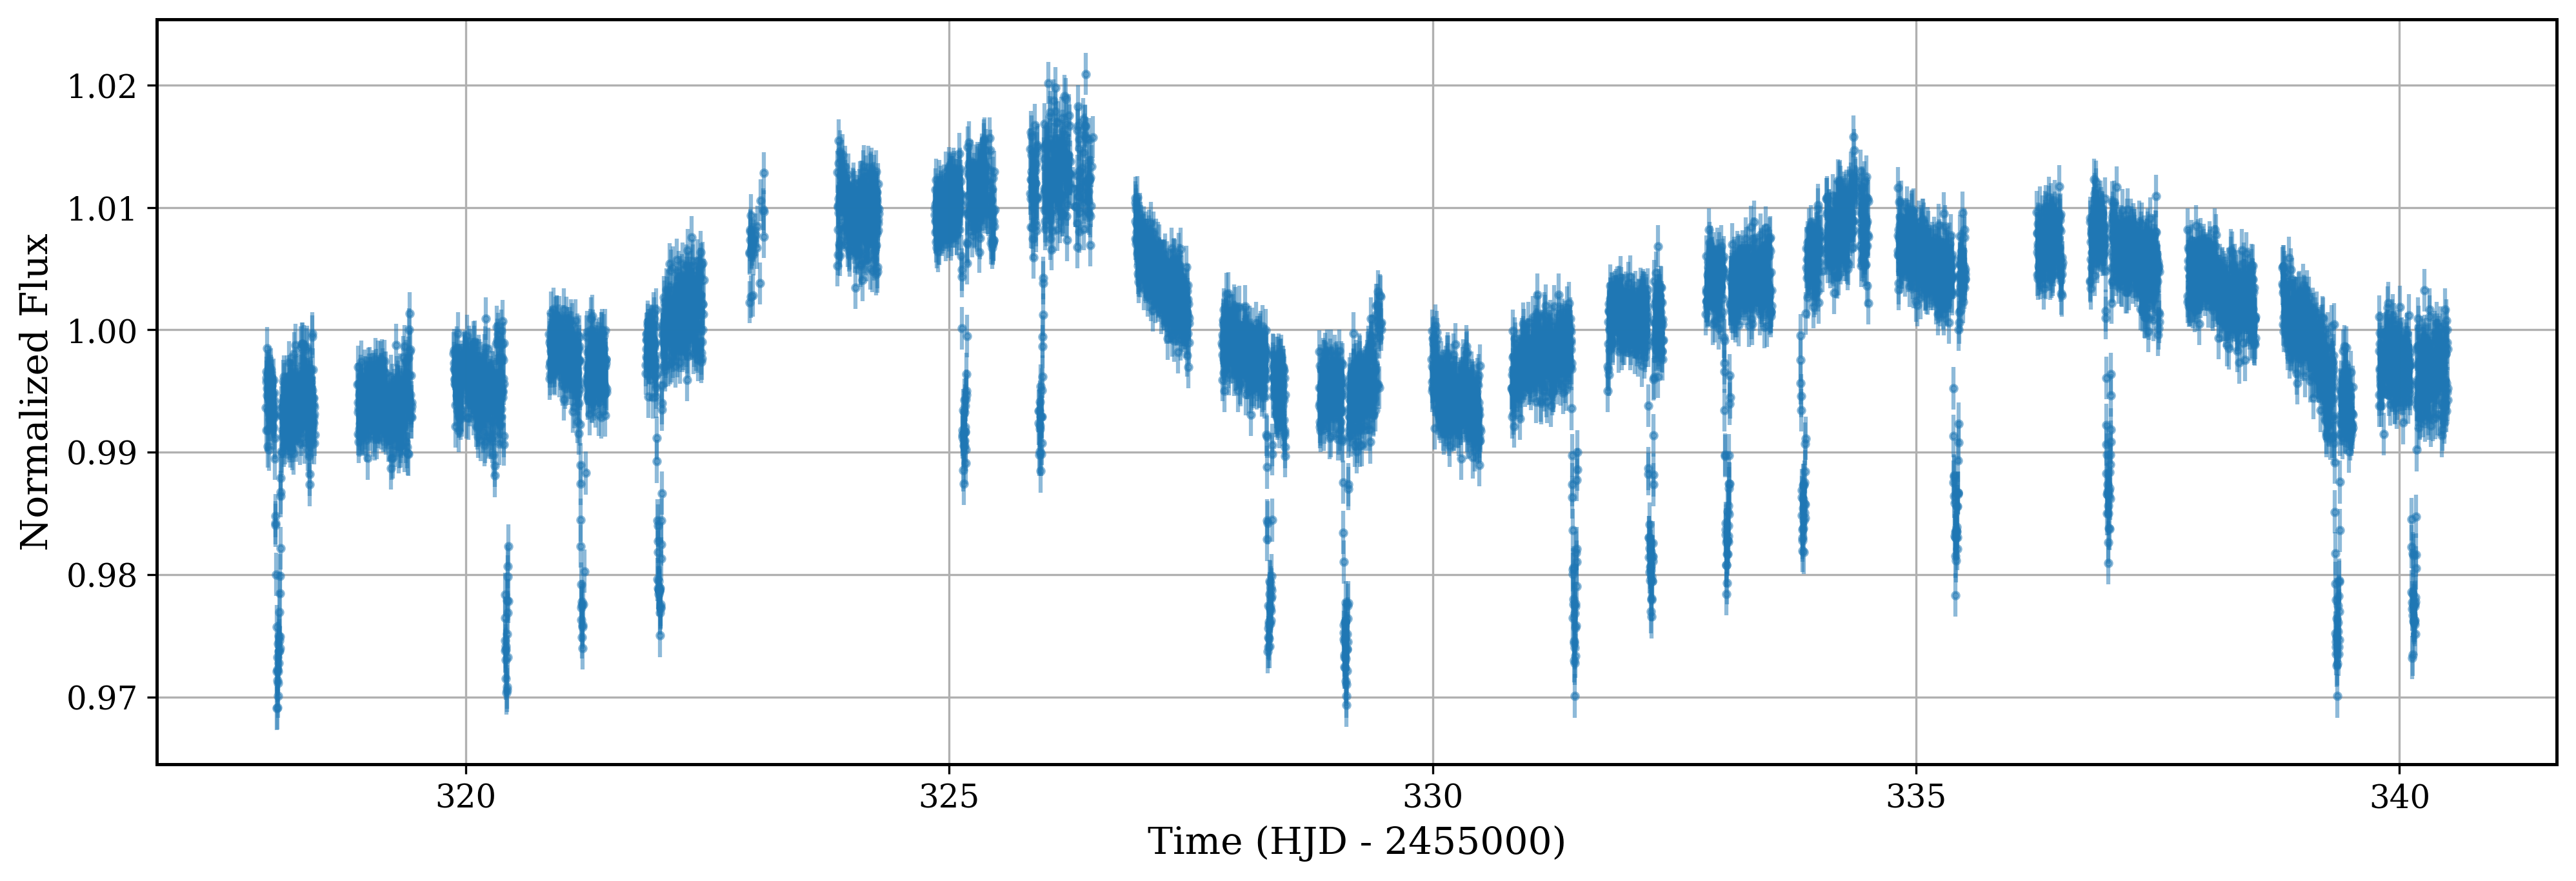

In [41]:
# Load the data, skipping lines that start with '#'
data = np.loadtxt('WASP-19b_lc.dat', comments='#')

# Extract columns
time = data[:, 0]            # HJD - 2455000
flux = data[:, 1]           # Normalized flux
flux_err = data[:, 2]       # Error in flux

# Plotting

# plt.errorbar(hjd, flux, yerr=flux_err, fmt='o', markersize=0.3, color='red', ecolor='k', capsize=2, label='WASP-19b')
# plt.xlabel('HJD - 2455000')
# plt.ylabel('Normalized Flux')
# plt.title('WASP-19b Light Curve')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(16, 5))
# plt.plot(tim1, fl1, '.')
plt.errorbar(time, flux, yerr=flux_err, fmt='.', alpha=0.5)
# plt.errorbar(tim1, fl1, yerr=fle1, fmt='.')
plt.xlabel('Time (HJD - 2455000)')
plt.ylabel('Normalized Flux')
plt.grid()

## De-trending

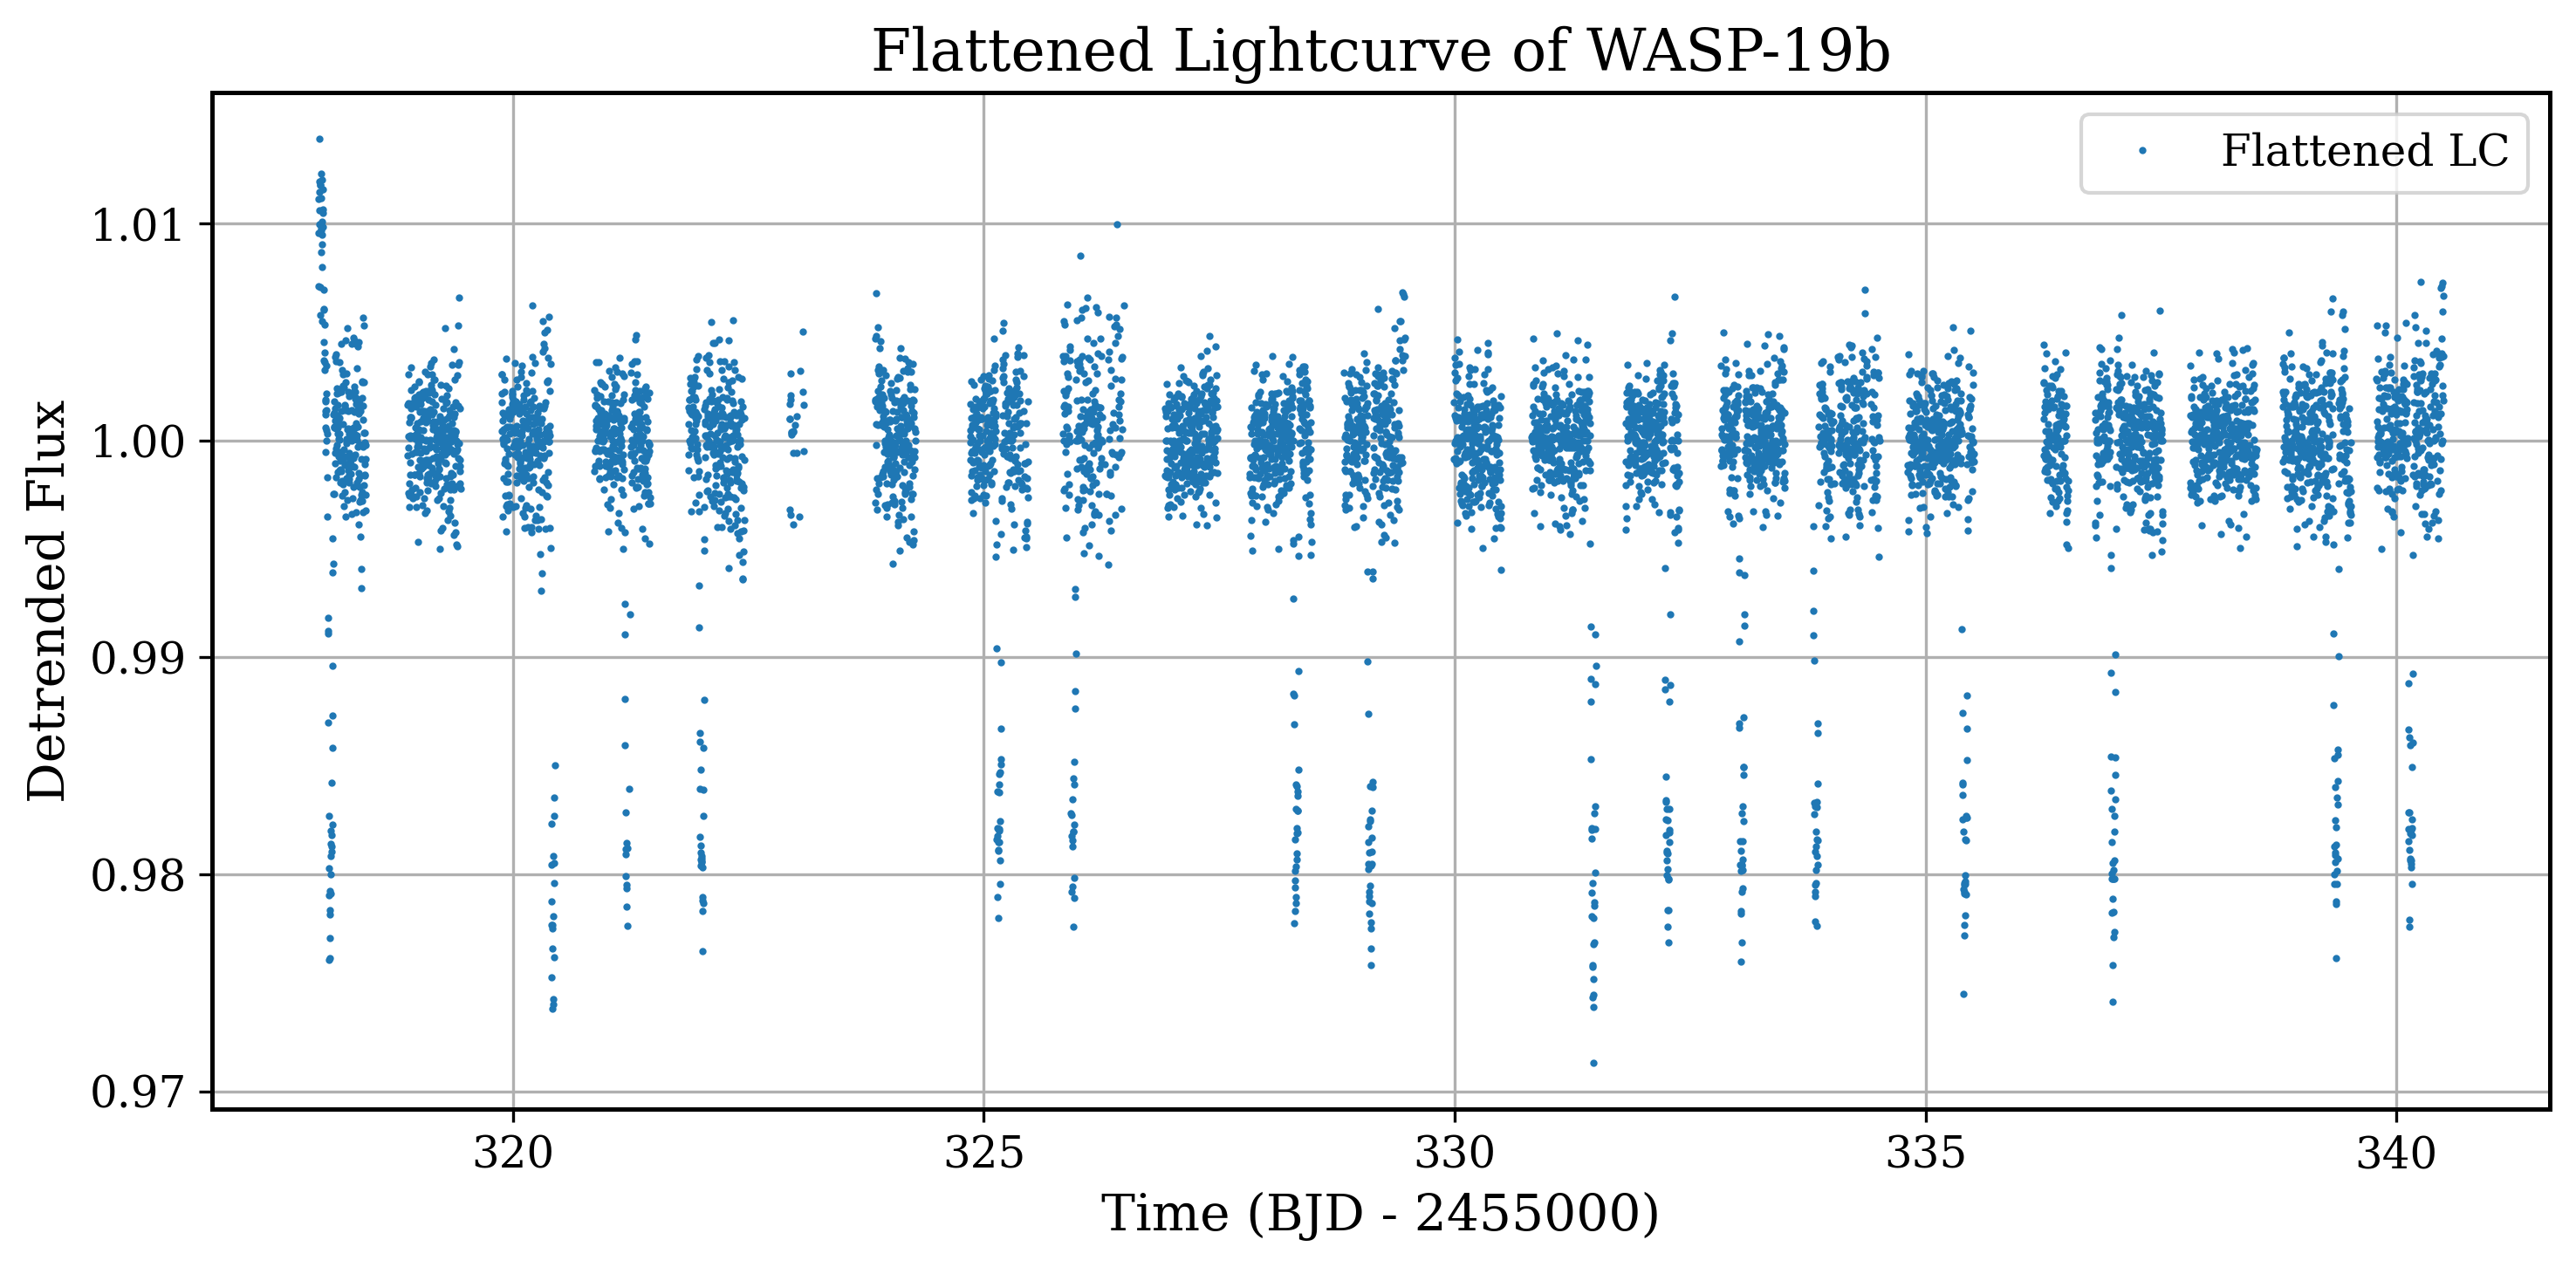

In [ ]:
from scipy.interpolate import UnivariateSpline
from scipy.signal import medfilt
from astropy.stats import sigma_clip

per, per_err = 0.7888385, 8e-7    
bjd0, bjd0_err = 2456402.7128, 0.0017  #2455317.26998
# t0 = 2455317.26998 - 2455000 
# phase = ((time - t0 + 0.5*per) % per) - 0.5*per
window = 101
trend = medfilt(flux, kernel_size=window)

# Flattened flux
f_flat = flux / trend
# f_clipped = sigma_clip(f_flat, sigma=5)

# Plot detrended lightcurve
plt.figure(figsize=(10, 5))
plt.plot(time, f_flat, '.', markersize=2, label='Flattened LC')
# plt.scatter(time[~f_clipped.mask], f_clipped.data[~f_clipped.mask], s=2)
plt.xlabel('Time (BJD - 2455000)')
plt.ylabel('Detrended Flux')
plt.title('Flattened Lightcurve of WASP-19b')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [77]:
tim, fl, fle = {}, {}, {}
tim['TESS2'], fl['TESS2'], fle['TESS2'] = time, f_flat, flux_err   # not TESS though, change later

In [96]:
# putting parameters of WASP-18b from literature

per, per_err = 0.7888385, 8e-7    
bjd0, bjd0_err = 2456402.7128, 0.0017

cycle = round((time[-1] - bjd0)/per)
tc1 = np.random.normal(bjd0, bjd0_err, 100000) + cycle*np.random.normal(per, per_err, 100000)
tc0, tc0_err = np.median(tc1), np.std(tc1)


tc2 = tc1 + np.random.normal(per, per_err, 100000)/2    ## eclipse time
tc_ecl, tc_ecl_err = np.median(tc2), np.std(tc2)

# Priors    #worked
par_P = ['P_p1', 't0_p1', 'p_p1_TESS2', 'b_p1', 'q1_TESS2', 'q2_TESS2',\
     'a_p1', 'fp_p1_TESS2', 't_secondary_p1', 'ecc_p1', 'omega_p1']
dist_P = ['normal', 'normal', 'uniform', 'uniform', 'uniform', 'uniform',\
     'loguniform', 'uniform', 'normal', 'uniform', 'uniform']
hyper_P = [[per, per_err], [tc0, 0.1], [0., 1.], [0., 1.], [0.,1.], [0.,1.],\
     [1., 5.], [0e-6, 390e-6], [tc_ecl, tc_ecl_err], [0., 0.1], [0., 360.0]]

##########   # debugging
# par_P = ['P_p1', 't0_p1', 'p_p1_TESS2', 'b_p1', 'q1_TESS2', 'q2_TESS2',
#          'a_p1', 'fp_p1_TESS2', 't_secondary_p1', 'sesinw_p1', 'secosw_p1']
# dist_P = ['normal', 'normal', 'uniform', 'uniform', 'uniform', 'uniform',
#           'loguniform', 'uniform', 'normal', 'uniform', 'uniform']
# hyper_P = [[per, per_err], [tc0, 0.1], [0., 1.], [0., 1.], [0., 1.], [0., 1.],
#            [1., 10.], [0.e-6, 500.e-6], [tc_ecl, tc_ecl_err], [-0.3, 0.3], [-0.3, 0.3]]
###########

par_ins = ['mdilution_TESS2', 'mflux_TESS2', 'sigma_w_TESS2']
dist_ins = ['fixed', 'normal', 'loguniform']
hyper_ins = [1., [0., 0.1], [0.1, 10000.]]

par_gp = ['GP_sigma_TESS2', 'GP_timescale_TESS2', 'GP_rho_TESS2']
dist_gp = ['loguniform', 'loguniform', 'loguniform']
hyper_gp = [[1e-5, 10000.], [1e-3, 1e2], [1e-3, 1e2]]

par_tot = par_P + par_ins + par_gp
dist_tot = dist_P + dist_ins + dist_gp
hyper_tot = hyper_P + hyper_ins + hyper_gp

priors_tot = juliet.utils.generate_priors(par_tot, dist_tot, hyper_tot)

In [97]:
# Fitting

# 
# dataset = juliet.load(priors=priors_tot, t_lc=tim, y_lc=fl, yerr_lc=fle,\
#     GP_regressors_lc=tim, out_folder=os.getcwd() + '/Analysis/Transit-Eclipse')
# res = dataset.fit(sampler = 'dynesty', nthreads=8)

dataset = juliet.load(priors=priors_tot, t_lc=tim, y_lc=fl, yerr_lc=fle,
                      GP_regressors_lc=tim, out_folder=os.getcwd() + '/Juliet_Analysis_WASP_19b/Transit-Eclipse-ecc')
res = dataset.fit(sampler='dynesty', nthreads=8, verbose=True)

27645it [09:15, 49.73it/s, +500 | bound: 335 | nc: 1 | ncall: 955440 | eff(%):  2.947 | loglstar:   -inf < 31455.962 <    inf | logz: 31401.241 +/-  0.333 | dlogz:  0.001 >  0.509]


In [98]:
os.system("cat Juliet_Analysis_WASP_19b/Transit-Eclipse-ecc/posteriors.dat")

# Parameter Name     	 	 Median       	 	 Upper 68 CI  	 	 Lower 68 CI 
P_p1               	 	 0.7888386145 	 	 0.0000005719 	 	 0.0000006972
t0_p1              	 	 340.9353697534 	 	 0.0001194185 	 	 0.0001837387
p_p1_TESS2         	 	 0.1428505482 	 	 0.0016407201 	 	 0.0028946721
b_p1               	 	 0.6730916079 	 	 0.0232052486 	 	 0.0302785823
q1_TESS2           	 	 0.3774048973 	 	 0.3639673281 	 	 0.1024679668
q2_TESS2           	 	 0.2427113622 	 	 0.3241516368 	 	 0.1463656738
a_p1               	 	 3.3532660312 	 	 0.1373644103 	 	 0.0792760039
fp_p1_TESS2        	 	 0.0002658155 	 	 0.0000901020 	 	 0.0001393913
t_secondary_p1     	 	 342.0302717227 	 	 1.8133626753 	 	 1.6865050977
ecc_p1             	 	 0.0670972114 	 	 0.0254242103 	 	 0.0274509615
omega_p1           	 	 43.3122516212 	 	 51.9706962397 	 	 20.3293752481
mflux_TESS2        	 	 -0.0010589161 	 	 0.0009497065 	 	 0.0013515461
sigma_w_TESS2      	 	 663.4262803189 	 	 29.9058683201 	 	 38.6570966163
GP_sig

0

ma_TESS2     	 	 0.0000117633 	 	 0.0000040477 	 	 0.0000012431
GP_timescale_TESS2 	 	 0.8198008631 	 	 0.2049269173 	 	 0.2169829636
GP_rho_TESS2       	 	 11.6765869946 	 	 35.2553094902 	 	 7.7113817144


In [99]:
# Making model
model = res.lc.evaluate('TESS2')
gp_model = res.lc.model['TESS2']['GP']
transit_model = res.lc.model['TESS2']['deterministic']
mflx = np.median(res.posteriors['posterior_samples']['mflux_TESS2'])
sigw = np.median(res.posteriors['posterior_samples']['sigma_w_TESS2'] * 1e-6)

(317.93643, 340.49918)

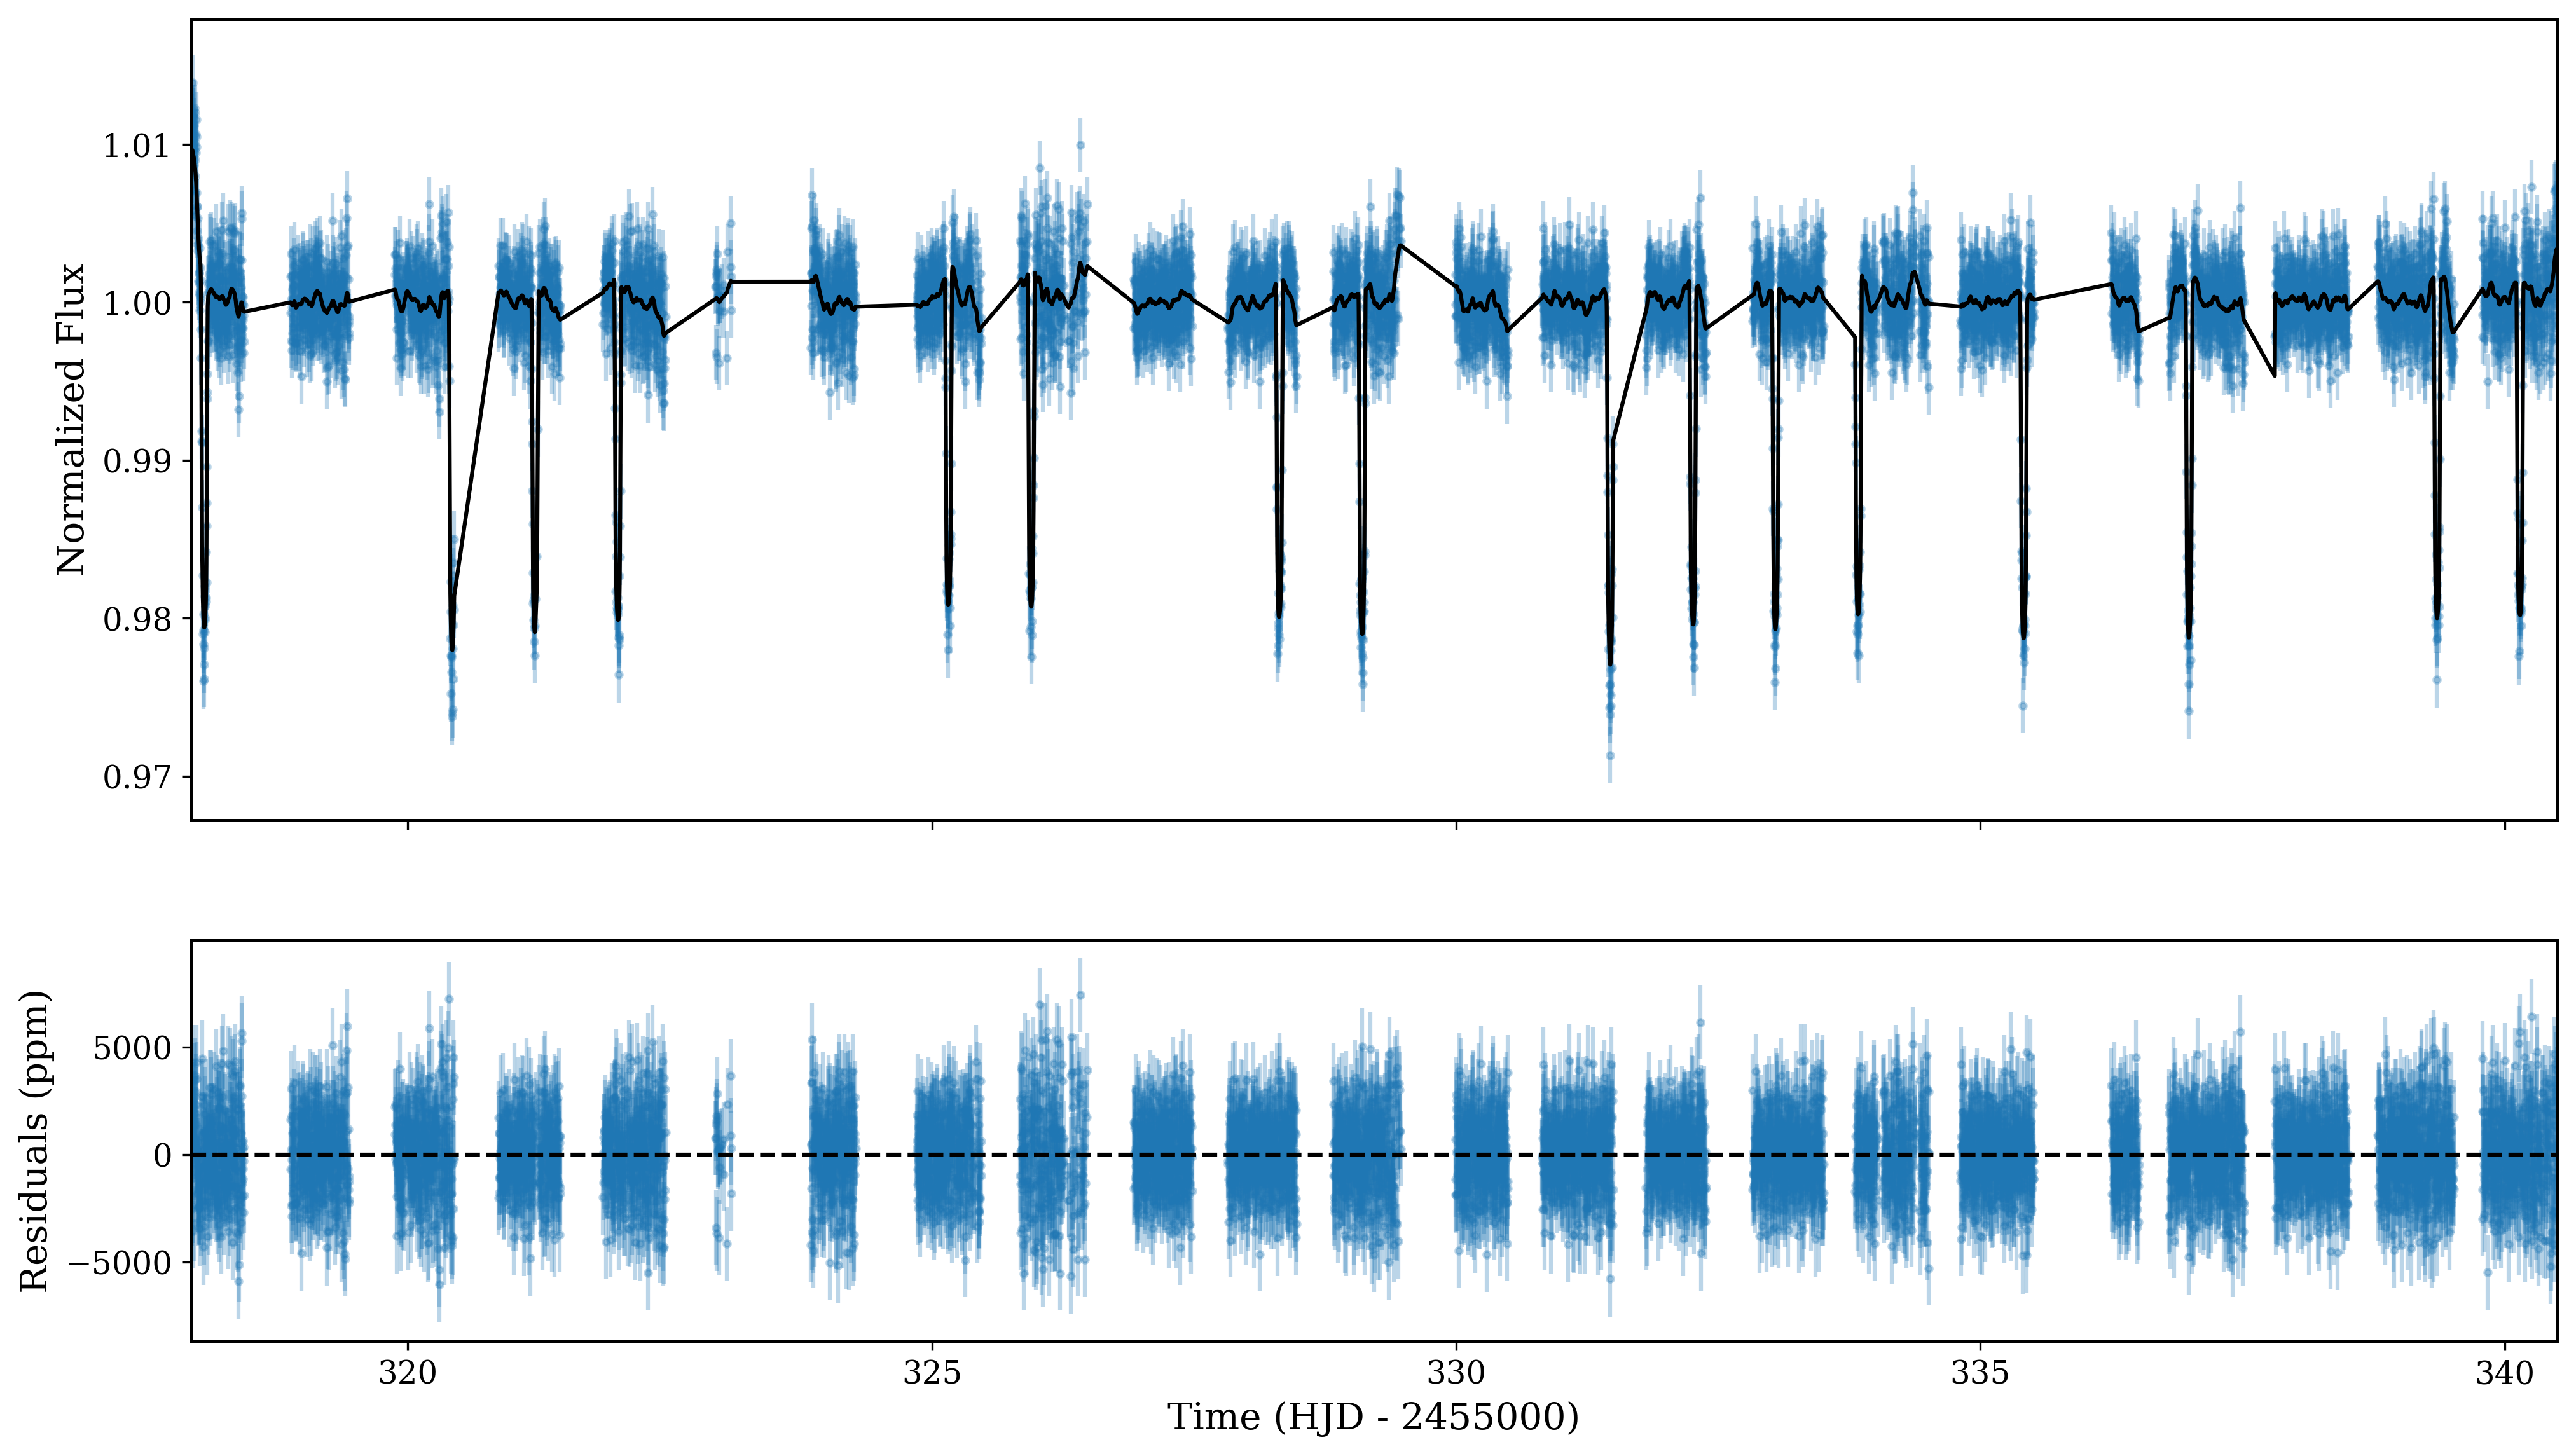

In [100]:
fig = plt.figure(figsize=(16,9))
gs = gd.GridSpec(2,1, height_ratios=[2,1])

# Lightcurve
ax1 = plt.subplot(gs[0])
ax1.errorbar(tim['TESS2'], fl['TESS2'], yerr=fle['TESS2'], fmt='.', alpha=0.3)
ax1.plot(tim['TESS2'], model, c='k', zorder=100)
ax1.set_ylabel('Normalized Flux')
ax1.set_xlim(np.min(tim['TESS2']), np.max(tim['TESS2']))
ax1.xaxis.set_major_formatter(plt.NullFormatter())
# fig.suptitle("WASP-18")

# Residual
ax2 = plt.subplot(gs[1])
ax2.errorbar(tim['TESS2'], (fl['TESS2']-model)*1e6, yerr=fle['TESS2']*1e6, fmt='.', alpha=0.3)
ax2.axhline(y=0.0, c='black', ls='--', zorder=100)
ax2.set_ylabel('Residuals (ppm)')
ax2.set_xlabel('Time (HJD - 2455000)')
ax2.set_xlim(np.min(tim['TESS2']), np.max(tim['TESS2']))

## Phase-folding

In [67]:
# t0 = res.posteriors['median']['t0_TESS2']
# t0

Text(0.5, 0, 'Phases (days)')

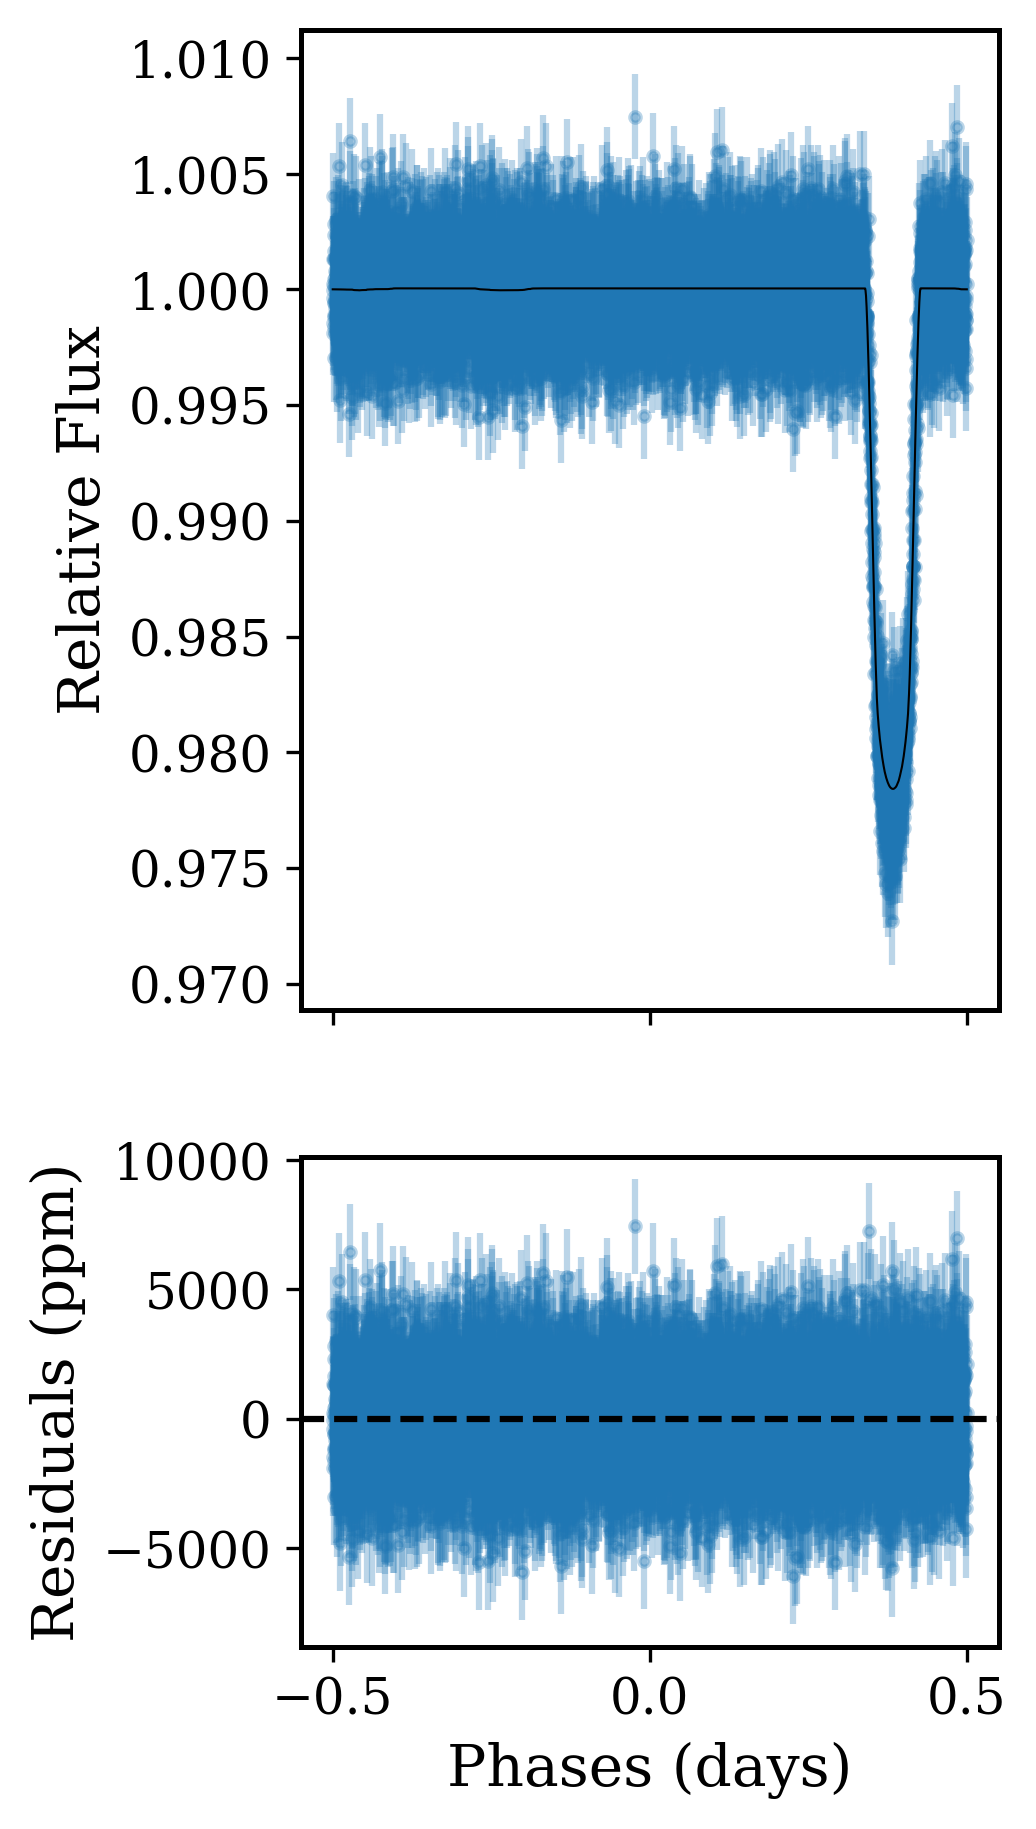

In [108]:
# phase = ((tim['TESS2'] - bjd0 +2455000 + 0.5 * per) % per) - 0.5 * per
phs = juliet.utils.get_phases(tim['TESS2'], per, bjd0)#, phmin=-0.8)
idx = np.argsort(phs)

fig = plt.figure(figsize=(3,7))
gs = gd.GridSpec(2,1, height_ratios=[2,1])


ax1 = plt.subplot(gs[0])
ax1.errorbar(phs, (fl['TESS2']-gp_model) * (1 + mflx), yerr=np.sqrt(fle['TESS2']**2 + sigw**2),\
             fmt='.', alpha=0.3)
ax1.plot(phs[idx], transit_model[idx] * (1 + mflx), c='k', zorder=100, linewidth=0.5)
# ax1.text(0.47, 0.996, "Eclipse.... Woohoo", fontsize=12, color='red')
ax1.set_ylabel('Relative Flux')
# ax1.set_xlim(-0.1, 0.0)
#ax1.set_ylim(0.998, 1.002)
ax1.xaxis.set_major_formatter(plt.NullFormatter())


ax2 = plt.subplot(gs[1])
ax2.errorbar(phs, (fl['TESS2']-model)*1e6, yerr=np.sqrt(fle['TESS2']**2 + sigw**2) * 1e6,\
             fmt='.', alpha=0.3)
ax2.axhline(y=0.0, c='black', ls='--', zorder=100)
ax2.set_ylabel('Residuals (ppm)')
ax2.set_xlabel('Phases (days)')
# ax2.set_ylim(-2000, 2000)
# ax2.set_xlim(-0.1, 0.0)

## It is seen above that even though there is a slight dip at around -0.4 phase in the above figure, it is not significantly visible. So, more data from Spitzer or Kepler is required for further analysis to see if we can indeed find the ecc from the secondary eclipse for this candidate.